# Zadanie 1

Przypomnij sobie z wykładu, jak definiowana jest epistaza i jak można ją oszacować empirycznie.

Wybierz jedną z reprezentacji genetycznych: **f9** lub **f1**.
<p style="color:red; font-weight:bold;">
UWAGA: Reprezentacja <code>f9</code> jest znacznie łatwiejsza do analizy epistazy niż <code>f1</code>.
Po usunięciu dowolnego genu genotyp w <code>f9</code> pozostaje poprawny (legalny),
co znacząco upraszcza eksperymenty polegające na usuwaniu genów i liczeniu efektów epistatycznych.
</p>

Tak jak poprzednio, wyewoluuj kilka wysokich konstrukcji (kryterium "vertpos") używając parametrów `eval-allcriteria.sim`;`deterministic.sim`;`sample-period-2.sim`;`only-body.sim`.

In [1]:
import subprocess
import sys
from pathlib import Path

def run_evolution(popsize=80, generations=100):
    FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
    LIB_DIR = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53"
    FS_SCRIPT = FRAMSPY_DIR / "FramsticksEvolution.py"

    sim_files = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"
    opt = "vertpos"
    max_numparts = "30"
    hof_size = "1"
    F = 9

    out_dir = FRAMSPY_DIR / "results" / "epistasis"
    hof_dir = out_dir / "HallOfFame"
    out_dir.mkdir(parents=True, exist_ok=True)
    hof_dir.mkdir(parents=True, exist_ok=True)

    for run_id in range(10): 
        hof_file = hof_dir / f"HoF-f{F}-run{run_id:03d}.gen"

        args = [
            sys.executable,
            str(FS_SCRIPT),
            "-path", LIB_DIR,
            "-sim", sim_files,
            "-opt", opt,
            "-max_numparts", max_numparts,
            "-genformat", str(F),
            "-popsize", str(popsize),
            "-generations", str(generations),
            "-hof_size", hof_size,
            "-hof_savefile", str(hof_file)
        ]

        result_file = out_dir / f"results-f{F}-run{run_id:03d}.txt"

        with result_file.open("w", encoding="utf-8") as fout:
            try:
                subprocess.run(
                    args,
                    cwd=str(FRAMSPY_DIR),
                    stdout=fout,
                    stderr=subprocess.STDOUT,
                    check=True
                )
            except subprocess.CalledProcessError as e:
                print(f"Run {run_id} -> process exited with code {e.returncode}")
            except Exception as e:
                print(f"Run {run_id} -> unexpected error: {e}")


In [ ]:
run_evolution()

In [3]:
import re
import pandas as pd
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
results_folder = FRAMSPY_DIR / "results" / "epistasis"
F = 9

files = [
    f for f in results_folder.iterdir()
    if f.name.startswith(f"results-f{F}-run") and f.suffix == ".txt"
]

all_data = []

for file_path in files:
    file_name = file_path.name

    match = re.match(rf"results-f{re.escape(str(F))}-run(\d+)\.txt", file_name)

    if not match:
        continue

    iteration = int(match.group(1))

    with file_path.open("r", encoding="utf-8") as f:
        lines = f.readlines()

    start_index = None
    for i, line in enumerate(lines):
        if line.strip().startswith("gen"):
            start_index = i
            break

    if start_index is None:
        continue

    for row in lines[start_index + 1:]:
        parts = re.split(r"\s+", row.strip())
        if len(parts) < 6:
            continue

        try:
            gen = int(parts[0])
            nevals = int(parts[1])
            avg = float(parts[2])
            stddev = float(parts[3])
            min_val = float(parts[4])
            max_val = float(parts[5])
        except ValueError:
            continue

        all_data.append({
            "gen": gen,
            "nevals": nevals,
            "avg": avg,
            "stddev": stddev,
            "min": min_val,
            "max": max_val,
            "iteration": iteration
        })

df = pd.DataFrame(all_data)

if not df.empty:
    df["cumulative_nevals"] = df.groupby("iteration")["nevals"].cumsum()
    df.to_csv("genotype_results.csv", index=False)


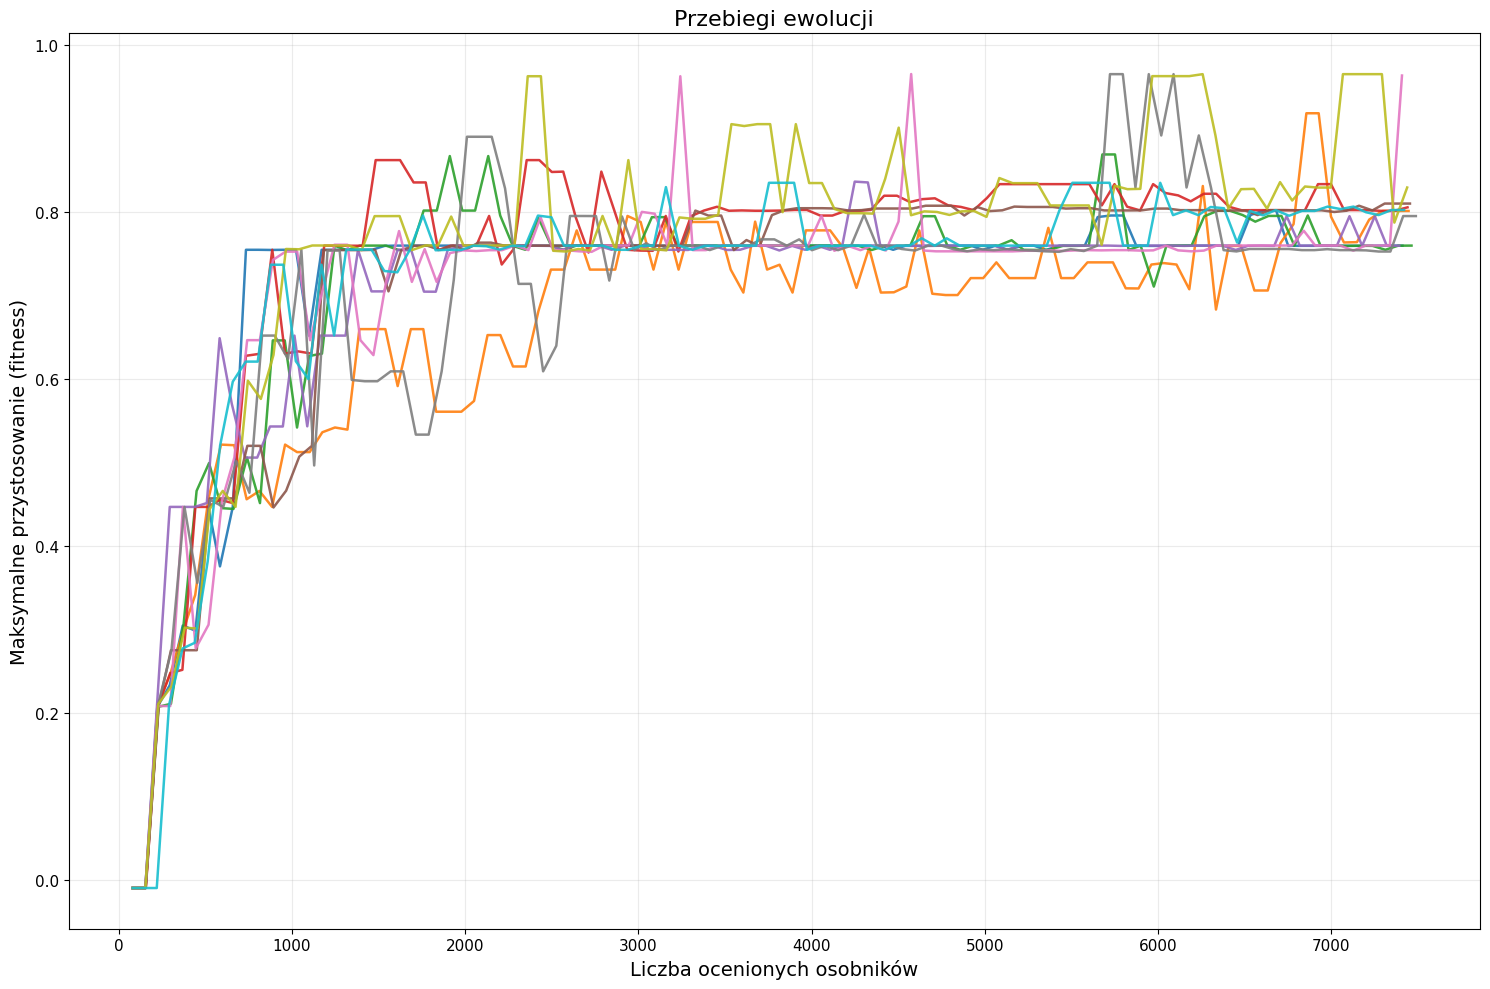

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

results_csv = "genotype_results.csv"

df = pd.read_csv(results_csv)
df["cumulative_nevals"] = df.groupby("iteration")["nevals"].cumsum()

plt.figure(figsize=(15, 10), dpi=100)

runs = sorted(df["iteration"].unique())
palette = sns.color_palette("tab10", n_colors=len(runs))

for run_id, color in zip(runs, palette):
    df_run = (
        df[df["iteration"] == run_id]
        .sort_values("cumulative_nevals")
    )

    if df_run.empty:
        continue

    plt.plot(
        df_run["cumulative_nevals"],
        df_run["max"],
        label=f"Run {run_id}",
        color=color,
        linewidth=1.8,
        alpha=0.9
    )

plt.title(
    "Przebiegi ewolucji",
    fontsize=16
)
plt.xlabel("Liczba ocenionych osobników", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

plt.savefig("przebiegi_ewolucji.png", dpi=200)
plt.show()

Z uzyskanych konstrukcji wybierz kilka różniących się (co najmniej trzy). Możesz też dołączyć jeden prosty, ręcznie zbudowany genotyp, jeśli chcesz zobaczyć, jak działa wyznaczanie epistazy dla łatwego do analizy, własnego pomysłu rozwiązania.

In [5]:
from pathlib import Path
import shutil
import itertools

BASE_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
HOF_DIR = BASE_DIR / "results" / "epistasis" / "HallOfFame"
OUT_DIR = BASE_DIR / "results" / "epistasis" / "most_diverse_3"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def read_genotype(file_path):
    lines = file_path.read_text(encoding="utf-8").splitlines()
    genotype_lines = []
    reading = False
    for line in lines:
        line = line.strip()
        if not line or line.startswith("org:"):
            continue
        if line.startswith("genotype:"):
            reading = True
            val = line[len("genotype:"):].strip()
            if val and val != "~":
                genotype_lines.append(val.replace("~", ""))
            continue
        if reading:
            if line.startswith("vertpos:"):
                break
            if line != "~":
                genotype_lines.append(line.replace("~", ""))
    return "\n".join(genotype_lines).strip()

def levenshtein(a, b):
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        current = [i]
        for j, cb in enumerate(b, 1):
            insert = current[j - 1] + 1
            delete = previous[j] + 1
            replace = previous[j - 1] + (ca != cb)
            current.append(min(insert, delete, replace))
        previous = current
    return previous[-1]

genotypes = []

for file in HOF_DIR.iterdir():
    if file.suffix != ".gen":
        continue
    try:
        g = read_genotype(file)
        if g:
            genotypes.append((file, g))
    except Exception as e:
        print(f"Error reading genotype from {file.name}: {e}")

if len(genotypes) < 3:
    print("Error: fewer than 3 valid genotypes found.")
    exit(1)

best_combo = None
best_score = -1

for combo in itertools.combinations(genotypes, 3):
    try:
        (_, a), (_, b), (_, c) = combo
        score = (
            levenshtein(a, b) +
            levenshtein(a, c) +
            levenshtein(b, c)
        )
        if score > best_score:
            best_score = score
            best_combo = combo
    except Exception as e:
        print(f"Error computing Levenshtein distance: {e}")

if best_combo is None:
    print("Error: could not determine the most diverse genotype set.")
    exit(1)

for file_path, _ in best_combo:
    try:
        shutil.copy(file_path, OUT_DIR / file_path.name)
    except Exception as e:
        print(f"Error copying file {file_path.name}: {e}")

Zwizualizuj epistazę (macierz 2D) pomiędzy wszystkimi parami genów. Jeśli wyłączenie genu skutkuje niepoprawnym genotypem, zignoruj ​​ten gen w analizie (nie wyłączaj go). Możesz wykorzystać poniższy kod jako inspirację:

```python
import argparse
import numpy as np
import os,sys
from FramsticksLib import FramsticksLib


def setstr(s, pos, char):
	assert len(char) == 1
	assert 0 <= pos < len(s)
	return s[:pos] + char + s[pos + 1:]

def show_array(arr):
	import matplotlib.pyplot as plt
	import matplotlib.colors as colors
	fig, ax = plt.subplots(figsize=(5, 5))
	from  matplotlib.colors import LinearSegmentedColormap
	red_white_green=LinearSegmentedColormap.from_list('my-gradient',["r", "w", "g"], N=256) # because matplotlib only provides red-YELLOW-green 
	im = ax.imshow(arr, cmap=red_white_green, norm=colors.CenteredNorm())
	# ...

def evaluate(prefix, geno): # TODO if needed, handle errors (due to invalid genotypes)
	return framsLib.evaluate([prefix + geno])[0]['evaluations']['']['vertpos']



# parsed_args = parseArguments()
# framsLib = FramsticksLib(parsed_args.path, parsed_args.lib, parsed_args.simsettings)

g = 'UDDDLFR...' # the genotype to test
prefix = '/*9*/'
fit = evaluate(prefix, g)
print(fit)
arr = np.full([len(g), len(g)], np.nan)
for i in range(len(g)):
	for j in range(len(g)): # the diagonal (i==j) stores the effect of disabling a single gene
		g2 = g
		g2 = setstr(g2, i, ' ')
		g2 = setstr(g2, j, ' ')
		g2 = g2.replace(' ', '')
		arr[i][j] = evaluate(prefix,g2) - fit

# calculate epistasis...
```
W odpowiedzi załącz otrzymane macierze i zinterpretuj wyniki. Czy macierze różnią się charakterystyką dla każdego z testowanych rozwiązań? Możesz wizualnie zidentyfikować, który gen odpowiada któremu fenowi (której części struktury 3D) używając pola tekstowego do edycji genów we Framsticks GUI.

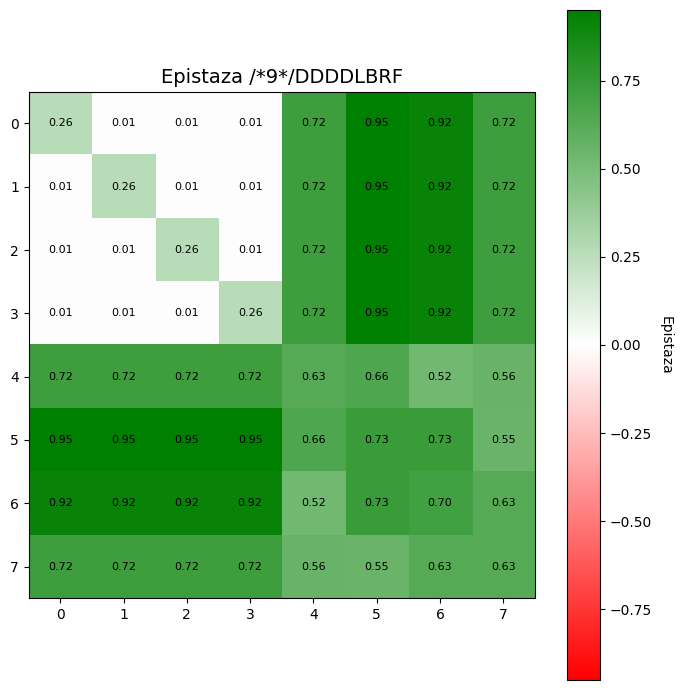

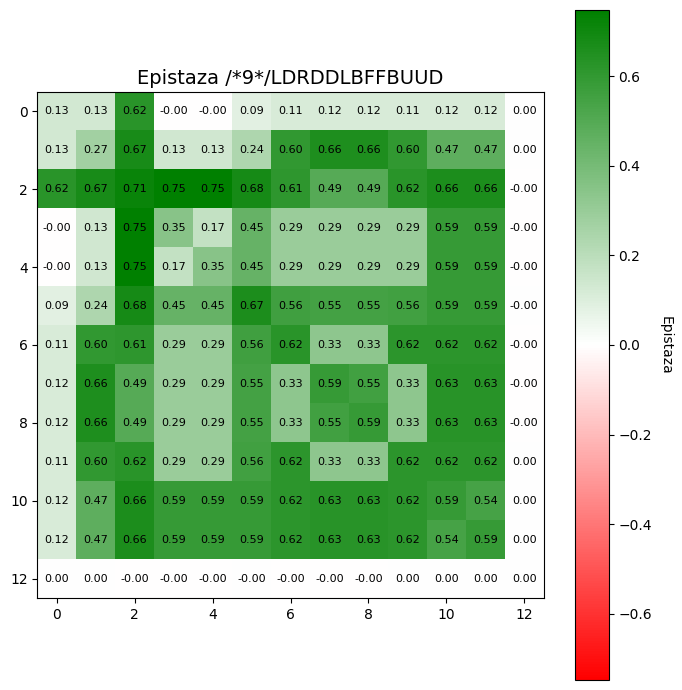

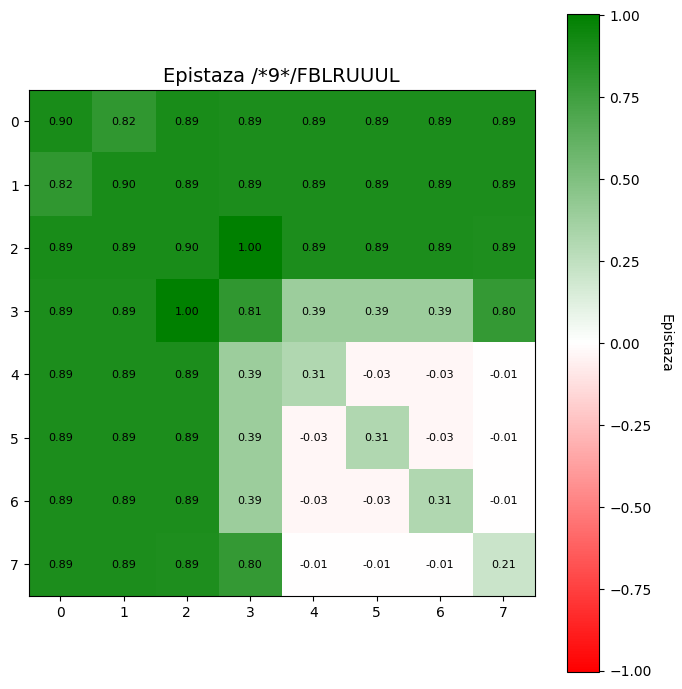

In [6]:
import numpy as np
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
LIB_DIR = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53"
LIB_NAME = "frams-objects.dll"
SIM_FILES = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"

GENOTYPES_DIR = FRAMSPY_DIR / "results" / "epistasis" / "most_diverse_3"
F = 9
PREFIX = f"/*{F}*/"
FITNESS_VALUE_INFEASIBLE_SOLUTION = -999999.0

def setstr(s, pos, char):
    return s[:pos] + char + s[pos + 1:]

def is_feasible(value):
    return value != FITNESS_VALUE_INFEASIBLE_SOLUTION

def show_and_save_epistasis_2D(arr, genotype):
    fig, ax = plt.subplots(figsize=(7, 7))
    cmap = LinearSegmentedColormap.from_list("red_white_green", ["red", "white", "green"], N=256)
    im = ax.imshow(arr, cmap=cmap, norm=colors.CenteredNorm())
    ax.set_title(f'Epistaza {genotype}', fontsize=14)
    N, _ = arr.shape
    for i in range(N):
        for j in range(N):
            if not np.isnan(arr[i, j]):
                ax.text(j, i, f"{arr[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Epistaza", rotation=270, labelpad=15)
    plt.tight_layout()
    safe_name = genotype.replace("/", "_").replace("*", "")
    filename = Path.cwd() / f"Epistaza_2D_osobnika_{safe_name}.png"
    plt.savefig(filename, dpi=200)
    plt.show()

def read_genotype(file_path):
    lines = file_path.read_text(encoding="utf-8").splitlines()
    genotype_lines = []
    reading = False
    for line in lines:
        line = line.strip()
        if not line or line.startswith("org:"):
            continue
        if line.startswith("genotype:"):
            reading = True
            val = line[len("genotype:"):].strip()
            if val and val != "~":
                genotype_lines.append(val.replace("~", ""))
            continue
        if reading:
            if line.startswith("vertpos:"):
                break
            if line != "~":
                genotype_lines.append(line.replace("~", ""))
    genotype = "".join(genotype_lines).strip()
    if not genotype.startswith("/*"):
        genotype = PREFIX + genotype
    return genotype

def initialize_framslib():
    sys.path.insert(0, str(FRAMSPY_DIR))
    from FramsticksLib import FramsticksLib
    sys.path.pop(0)
    with open(os.devnull, "w") as fnull:
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = fnull
        try:
            lib = FramsticksLib(LIB_DIR, LIB_NAME, SIM_FILES)
        finally:
            sys.stdout, sys.stderr = old_out, old_err
    return lib

def evaluate(frams_lib, genotype):
    try:
        result = frams_lib.evaluate([genotype])
        return result[0]["evaluations"][""]["vertpos"]
    except:
        return FITNESS_VALUE_INFEASIBLE_SOLUTION

framsLib = initialize_framslib()

for gen_file in GENOTYPES_DIR.glob("*.gen"):
    full_genotype = read_genotype(gen_file)
    prefix_len = len(PREFIX)
    body = full_genotype[prefix_len:]
    fit = evaluate(framsLib, full_genotype)
    if not is_feasible(fit):
        print("Original genotype infeasible → skipped")
        continue

    N = len(body)
    arr = np.full((N, N), np.nan)

    single_fitness = [None] * N
    for i in range(N):
        body_list = list(body)
        body_list[i] = ""
        g1 = PREFIX + "".join(body_list)
        f1 = evaluate(framsLib, g1)
        if is_feasible(f1):
            single_fitness[i] = f1

    for i in range(N):
        for j in range(i, N):
            body_list = list(body)
            body_list[i] = ""
            body_list[j] = ""
            g2 = PREFIX + "".join(body_list)
            fAB = evaluate(framsLib, g2)

            if not is_feasible(fAB):
                continue
            if single_fitness[i] is None or single_fitness[j] is None:
                continue

            fA = single_fitness[i]
            fB = single_fitness[j]
            epistasis = fAB - (fA + fB - fit)

            arr[i, j] = epistasis
            arr[j, i] = epistasis

    show_and_save_epistasis_2D(arr, full_genotype)


W analizie wykorzystano reprezentację genetyczną **f9**, a epistazę wyznaczono metodą **DLED** (Dual-Locus Epistasis Detection). Epistaza została zdefiniowana jako odchylenie od addytywności i obliczona wzorem $E = f_{AB} - (f_A + f_B - f_{orig})$, gdzie $f_{AB}$ to fitness osobnika z podwójnym knockoutem, a $f_A$ i $f_B$ to fitnessy przy pojedynczych usunięciach genów.

Interpretacja wyników na macierzach:
* **Zielony (E > 0):** epistaza pozytywna, czyli synergiczne działanie genów; dominująca w testowanych konstrukcjach, charakterystyczna dla struktur modularnych.
* **Biały (E ≈ 0):** brak epistazy, addytywność efektów genów; geny działają niezależnie, efekty się sumują.
* **Czerwony (E < 0):** epistaza negatywna, antagonizm; usunięcie obu genów jest bardziej szkodliwe niż suma efektów pojedynczych knockoutów.

Wizualna analiza macierzy pozwala zauważyć różnice w architekturze osobników. W złożonych genotypach, np. `LDRDDLBFFBUUD`, intensywne pionowe i poziome pasma odpowiadają genom kluczowym pełniącym funkcję stabilizujących węzłów. Ciemnozielone bloki wskazują na silną integrację modułów funkcjonalnych, natomiast sekwencje powtarzalne (`DDD`) odpowiadają segmentom działającym niezależnie i addytywnie.

# Zadanie 2

Powtórz eksperyment jak w poprzednim pytaniu, ale tym razem zbadaj epistazę wśród wszystkich trójek genów. Jako punkt odniesienia (potrzebny do oszacowania wielkości epistazy poprzez obliczenie różnicy) porównaj oddzielnie dwa warianty, które zostały już obliczone i wartości są znane z poprzedniego pytania: wpływ pojedynczych genów w trójkach oraz wpływ wszystkich par genów występujących w trójkach (konkretne wzory zostały omówione podczas niedawnego wykładu; podaj wykorzystane wzory w swojej odpowiedzi).

Zwizualizuj wyniki jako "3D heatmap" (małe kulki ułożone w siatkę 3D, pokolorowane wedle tej samej zasady, co poprzednio).

Przeanalizuj wyniki i opisz wnioski tak jak wcześniej. Dla wszystkich punktów odniesienia i przetestowanych genotypów porównaj sumę surowych wartości epistazy (tzn. `sum(epistasis_3d_matrix)`) i sumę wartości bezwzględnych (tzn. `sum(abs(epistasis_3d_matrix))`). Który z dwóch punktów odniesienia okazał się bardziej użyteczny (zakładając, że teraz chcemy odkryć nowe informacje dotyczące interakcji między trójkami genów, a nie te same informacje, które już znamy o parach) i dlaczego?

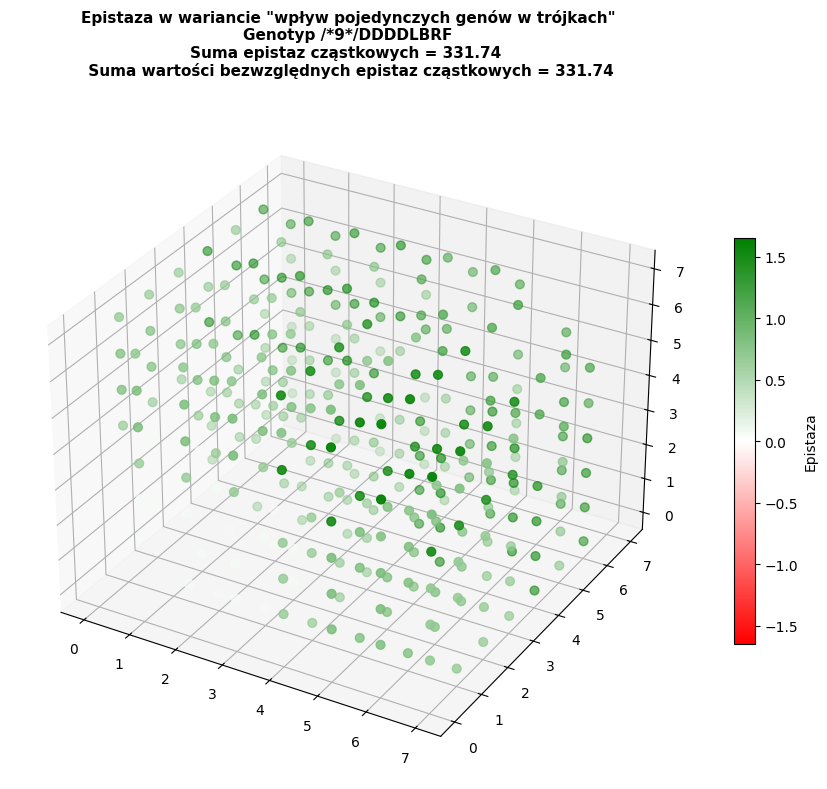

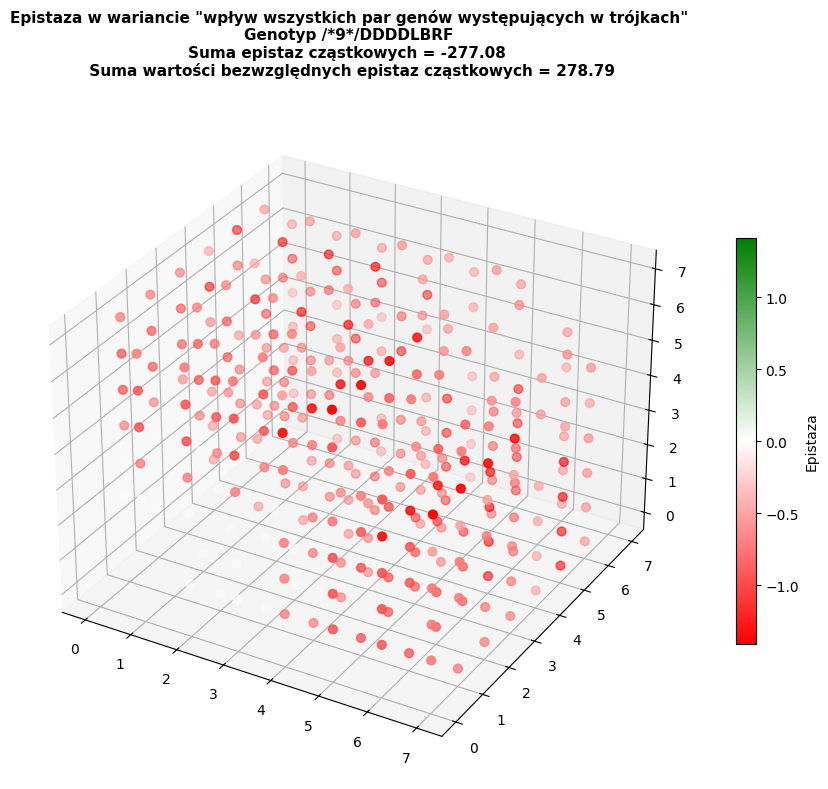

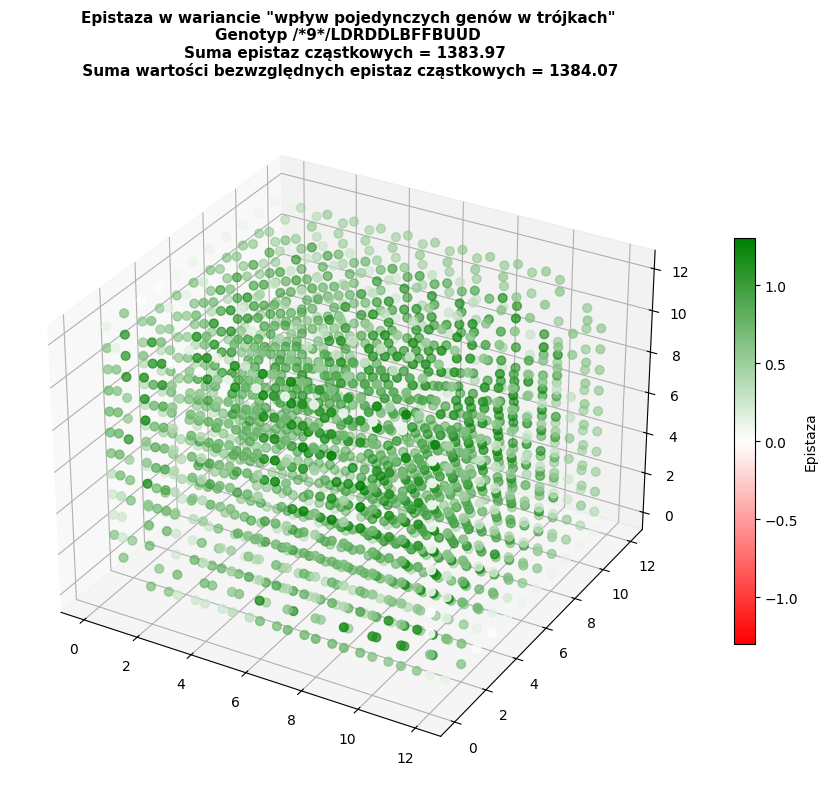

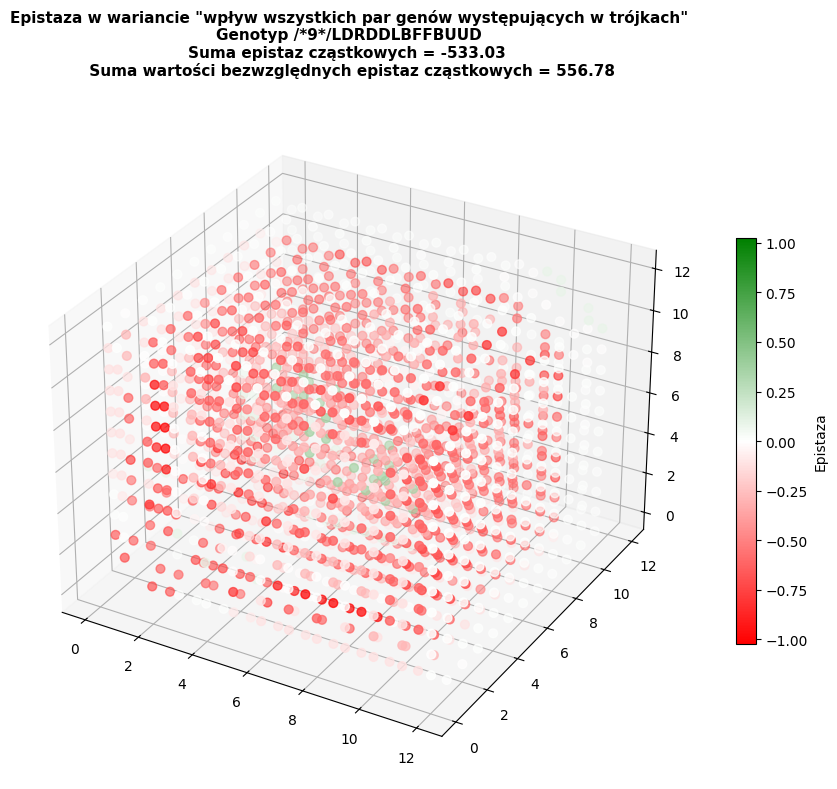

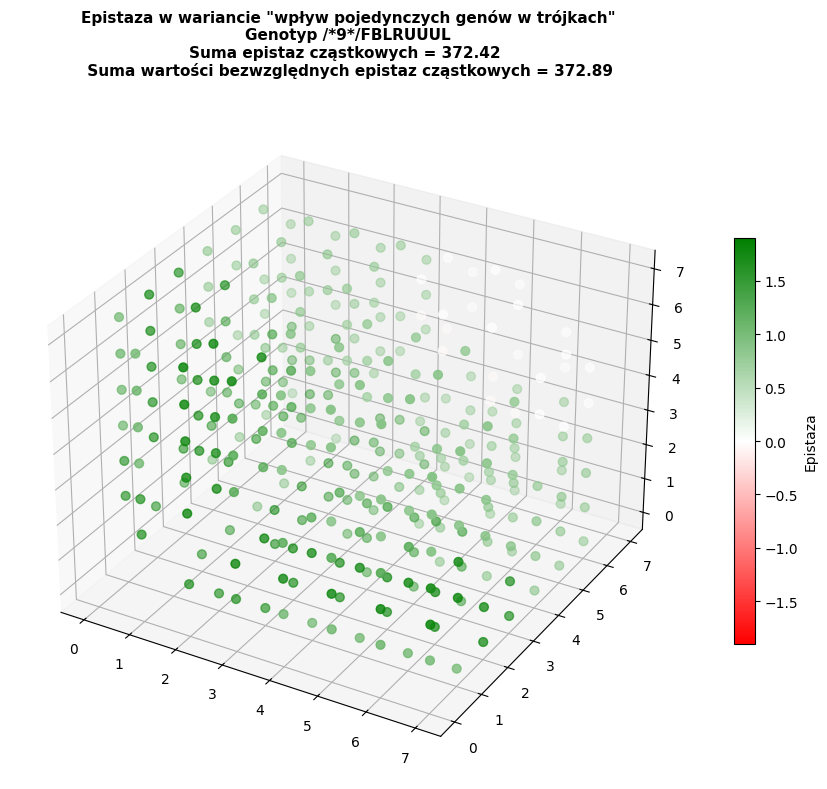

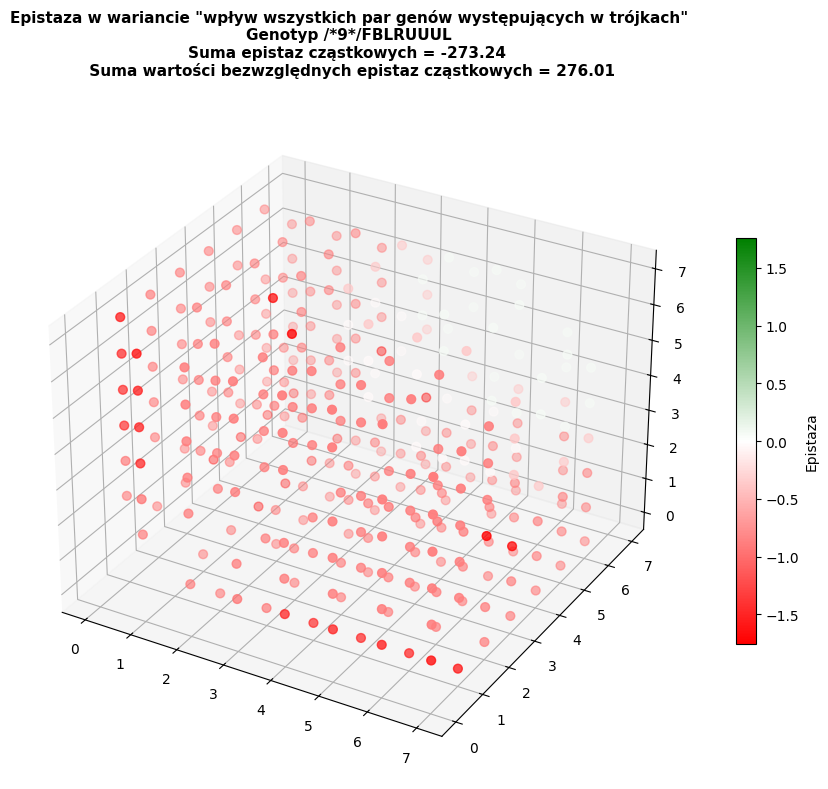

In [7]:
import numpy as np
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
LIB_DIR = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53"
LIB_NAME = "frams-objects.dll"
SIM_FILES = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"
GENOTYPES_DIR = FRAMSPY_DIR / "results" / "epistasis" / "most_diverse_3"
F = 9
PREFIX = f"/*{F}*/"
FITNESS_VALUE_INFEASIBLE_SOLUTION = -999999.0

def is_feasible(value):
    return value != FITNESS_VALUE_INFEASIBLE_SOLUTION

def show_and_save_epistasis_3D(arr, genotype, variant_name):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    cmap = LinearSegmentedColormap.from_list("red_white_green", ["red", "white", "green"], N=256)
    N = arr.shape[0]
    X, Y, Z = np.meshgrid(range(N), range(N), range(N))
    xs, ys, zs, cs = X.flatten(), Y.flatten(), Z.flatten(), arr.flatten()
    mask = ~np.isnan(cs)
    xs, ys, zs, cs = xs[mask], ys[mask], zs[mask], cs[mask]
    img = ax.scatter(xs, ys, zs, c=cs, cmap=cmap, norm=colors.CenteredNorm(), s=40)
    sum_raw = np.nansum(arr)
    sum_abs = np.nansum(np.abs(arr))
    title_text = (
        f'Epistaza w wariancie "{variant_name}"\n'
        f'Genotyp {genotype}\n'
        f'Suma epistaz cząstkowych = {sum_raw:.2f} \n Suma wartości bezwzględnych epistaz cząstkowych = {sum_abs:.2f}'
    )
    ax.set_title(title_text, fontsize=11, pad=20, fontweight='bold')
    cbar = plt.colorbar(img, ax=ax, shrink=0.6)
    cbar.set_label('Epistaza')
    plt.tight_layout()
    safe_name = genotype.replace("/", "_").replace("*", "")
    filename = Path.cwd() / f"epistaza_3D_{variant_name}_osobnika_{safe_name}.png"
    plt.savefig(filename, dpi=200)
    plt.show()

def read_genotype(file_path):
    lines = file_path.read_text(encoding="utf-8").splitlines()
    genotype_lines = []
    reading = False
    for line in lines:
        line = line.strip()
        if not line or line.startswith("org:"): continue
        if line.startswith("genotype:"):
            reading = True
            val = line[len("genotype:"):].strip()
            if val and val != "~": genotype_lines.append(val.replace("~", ""))
            continue
        if reading:
            if line.startswith("vertpos:"): break
            if line != "~": genotype_lines.append(line.replace("~", ""))
    genotype = "".join(genotype_lines).strip()
    if not genotype.startswith("/*"): genotype = PREFIX + genotype
    return genotype

def initialize_framslib():
    sys.path.insert(0, str(FRAMSPY_DIR))
    from FramsticksLib import FramsticksLib
    sys.path.pop(0)
    with open(os.devnull, "w") as fnull:
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = fnull
        try:
            lib = FramsticksLib(LIB_DIR, LIB_NAME, SIM_FILES)
        finally:
            sys.stdout, sys.stderr = old_out, old_err
    return lib

def evaluate(frams_lib, genotype):
    try:
        result = frams_lib.evaluate([genotype])
        return result[0]["evaluations"][""]["vertpos"]
    except:
        return FITNESS_VALUE_INFEASIBLE_SOLUTION

framsLib = initialize_framslib()

for gen_file in GENOTYPES_DIR.glob("*.gen"):
    full_genotype = read_genotype(gen_file)
    body = full_genotype[len(PREFIX):]
    fit = evaluate(framsLib, full_genotype)
    if not is_feasible(fit): continue

    N = len(body)
    e_variant1 = np.full((N, N, N), np.nan)
    e_variant2 = np.full((N, N, N), np.nan)

    single_fit = [None] * N
    for i in range(N):
        bl = list(body); bl[i] = ""
        f = evaluate(framsLib, PREFIX + "".join(bl))
        if is_feasible(f): single_fit[i] = f

    for i, j, k in combinations(range(N), 3):
        if any(x is None for x in [single_fit[i], single_fit[j], single_fit[k]]): continue
        
        bl = list(body); bl[i]=bl[j]=""; fAB = evaluate(framsLib, PREFIX+"".join(bl))
        bl = list(body); bl[i]=bl[k]=""; fAC = evaluate(framsLib, PREFIX+"".join(bl))
        bl = list(body); bl[j]=bl[k]=""; fBC = evaluate(framsLib, PREFIX+"".join(bl))
        bl = list(body); bl[i]=bl[j]=bl[k]=""; fABC = evaluate(framsLib, PREFIX+"".join(bl))

        if not all(is_feasible(v) for v in [fAB, fAC, fBC, fABC]): continue

        v1 = fABC - (single_fit[i] + single_fit[j] + single_fit[k] - 2 * fit)
        v2 = fABC - (fAB + fAC + fBC - single_fit[i] - single_fit[j] - single_fit[k] + fit)

        for idx_tuple in [(i,j,k),(i,k,j),(j,i,k),(j,k,i),(k,i,j),(k,j,i)]:
            e_variant1[idx_tuple] = v1
            e_variant2[idx_tuple] = v2

    show_and_save_epistasis_3D(e_variant1, full_genotype, "wpływ pojedynczych genów w trójkach")
    show_and_save_epistasis_3D(e_variant2, full_genotype, "wpływ wszystkich par genów występujących w trójkach")

W analizie zbadano interakcje potrójnych knockoutów, stosując dwa punkty odniesienia oparte na zasadzie addytywności:

1. **Wariant 1 (Addytywność 1. stopnia):** $E_{ABC}^{(1)} = f_{ABC} - (f_A + f_B + f_C - 2f_{orig})$
2. **Wariant 2 (Addytywność 2. stopnia):** $E_{ABC}^{(2)} = f_{ABC} - (f_{AB} + f_{AC} + f_{BC} - f_A - f_B - f_C + f_{orig})$

Wizualizacje 3D ujawniają fundamentalną różnicę w interpretacji architektury genetycznej f9. Wariant 1 generuje wykresy niemal wyłącznie **zielone** (pozytywne), co potwierdza wysoką **redundancję** systemu – usunięcie trójki genów psuje osobnika znacznie mniej, niż wynikałoby to z sumy strat pojedynczych mutacji. Z kolei w Wariancie 2 dominuje kolor **czerwony** (negatywny). Oznacza to, że rzeczywista sprawność trójki ($f_{ABC}$) jest niższa niż przewidywania oparte na bardzo silnych interakcjach par. System wykazuje efekt nasycenia: o ile dwie mutacje są świetnie kompensowane przez mechanizmy nadmiarowości, o tyle trzecia przełamuje strukturę, co interpretujemy jako epistazę deminuującą.

Porównanie sumy surowej (`sum(E)`) oraz sumy wartości bezwzględnych (`sum(abs(E))`) dla obu wariantów wykazuje ich niemal pełną zbieżność (różnice są marginalne). Taki wynik świadczy o braku szumu informacyjnego i występowaniu jednolitego, globalnego trendu w całym genotypie. W architekturze f9 interakcje nie znoszą się wzajemnie, lecz konsekwentnie zmierzają w stronę nasycenia wytrzymałości strukturalnej.

Za zdecydowanie bardziej użyteczny uznano **Wariant 2 (względem par)**. Pozwala on wyjść poza oczywisty wniosek o współpracy genów (widoczny już w 2D i Wariancie 1) i dostarcza nowej wiedzy o **granicach redundancji**. Ujawnia on, że w f9 pary genów są jednostkami silnie nadmiarowymi, ale ich zdolność do asekuracji gwałtownie kończy się przy potrójnych uszkodzeniach. Monitorowanie obu sum w tym wariancie pozwala precyzyjnie określić, jak stabilna i napięta jest sieć powiązań wewnątrz danego osobnika, wskazując moment, w którym liniowe dokładanie szkód napotyka barierę systemową.